<h1 id="Lecture-6:-Time-series-reasoning-and-forecasting">Lecture 6: Time-series reasoning and forecasting</h1><p>Time order changes what the data can say. A forecast at time (t) may use only the information genuinely available at (t). This notebook uses daily service demand to examine structure, baselines, smoothing, ARIMA, validation, uncertainty, anomalies, and breaks.</p>

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from ds301.paths import project_root
ROOT = project_root()
TEAL,MINT,GOLD,CORAL,INK="#005F73","#0A9396","#EE9B00","#BB3E03","#1D3557"
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams.update({"figure.dpi":120,"font.size":11,"axes.titleweight":"bold"})
series=pd.read_csv(ROOT/"data/service_demand.csv",parse_dates=["date"]).sort_values("date")

<h2 id="Begin-with-the-dated-records">Begin with the dated records</h2><p>Each row records demand on one calendar day. Before estimating a trend, a seasonal pattern, or a forecast, inspect the date and the demand value together. Every later view transforms these same records, so the date order remains part of the evidence.</p>

In [2]:
series.head(14)

,date,demand,holiday,promotion
0,2024-01-01,113.6,0,0
1,2024-01-02,109.2,0,0
2,2024-01-03,120.1,0,0
3,2024-01-04,104.9,0,0
4,2024-01-05,112.5,0,0
5,2024-01-06,80.3,0,0
6,2024-01-07,102.3,0,1
7,2024-01-08,97.5,0,0
8,2024-01-09,119.9,0,0
9,2024-01-10,136.0,0,1


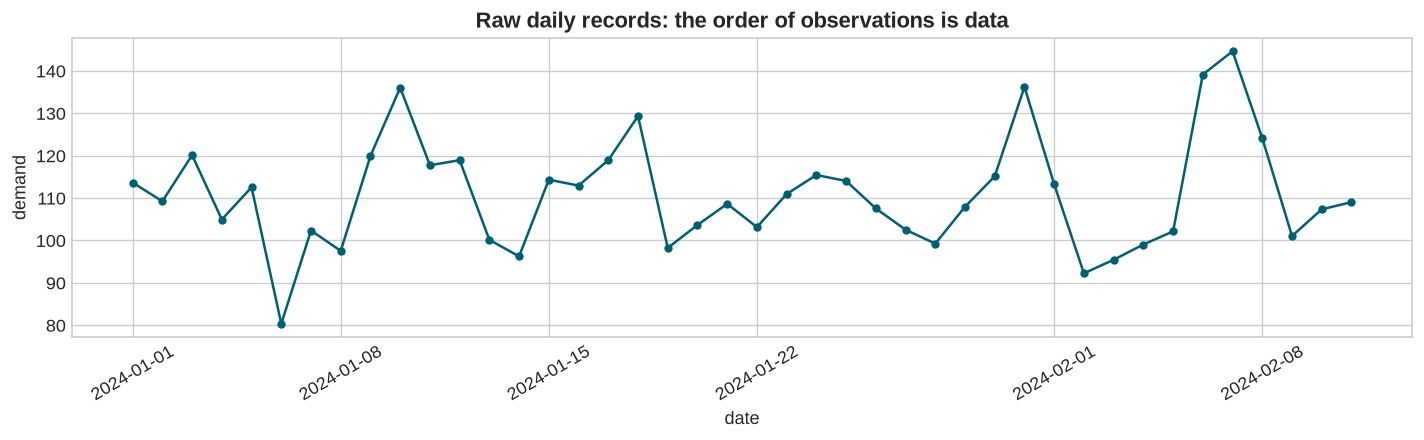

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.8))
raw_window = series.iloc[:42]
ax.plot(raw_window.date, raw_window.demand, "o-", color=TEAL, ms=4)
ax.set(title="Raw daily records: the order of observations is data", xlabel="date", ylabel="demand")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

<h2 id="1.-Cross-section,-time-series,-and-panel-data">1. Cross-section, time series, and panel data</h2><p>Cross-sectional data compares units at one moment. A time series follows one quantity through time. A panel follows several units through time. The decision determines the useful structure.</p>

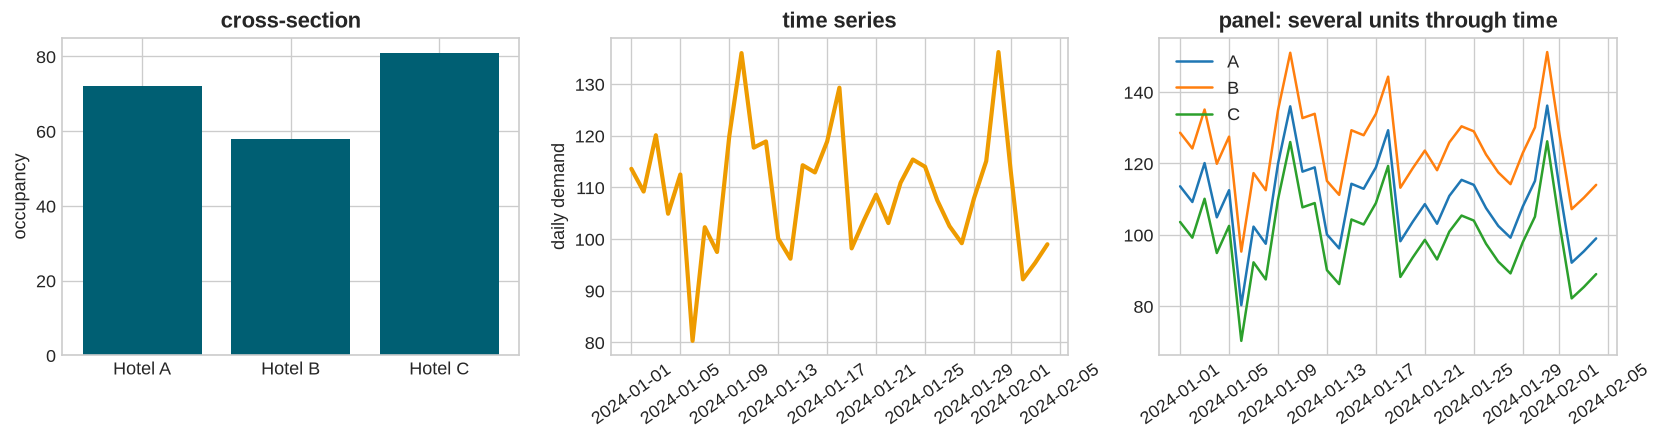

In [4]:
fig,axes=plt.subplots(1,3,figsize=(14,3.8))
axes[0].bar(["Hotel A","Hotel B","Hotel C"],[72,58,81],color=TEAL); axes[0].set(title="cross-section",ylabel="occupancy")
axes[1].plot(series.date.iloc[:35],series.demand.iloc[:35],c=GOLD,lw=2.5); axes[1].tick_params(axis="x",rotation=35); axes[1].set(title="time series",ylabel="daily demand")
for unit,offset in [("A",0),("B",15),("C",-10)]: axes[2].plot(series.date.iloc[:35],series.demand.iloc[:35]+offset,label=unit)
axes[2].legend(); axes[2].tick_params(axis="x",rotation=35); axes[2].set(title="panel: several units through time")
plt.tight_layout()

<h2 id="2.-Trend,-seasonality,-frequency,-and-missing-periods">2. Trend, seasonality, frequency, and missing periods</h2><p>Trend describes a long-run movement. Seasonality repeats on a known calendar. Frequency is a modelling choice: daily detail can reveal weekly patterns that disappear in monthly aggregation.</p>

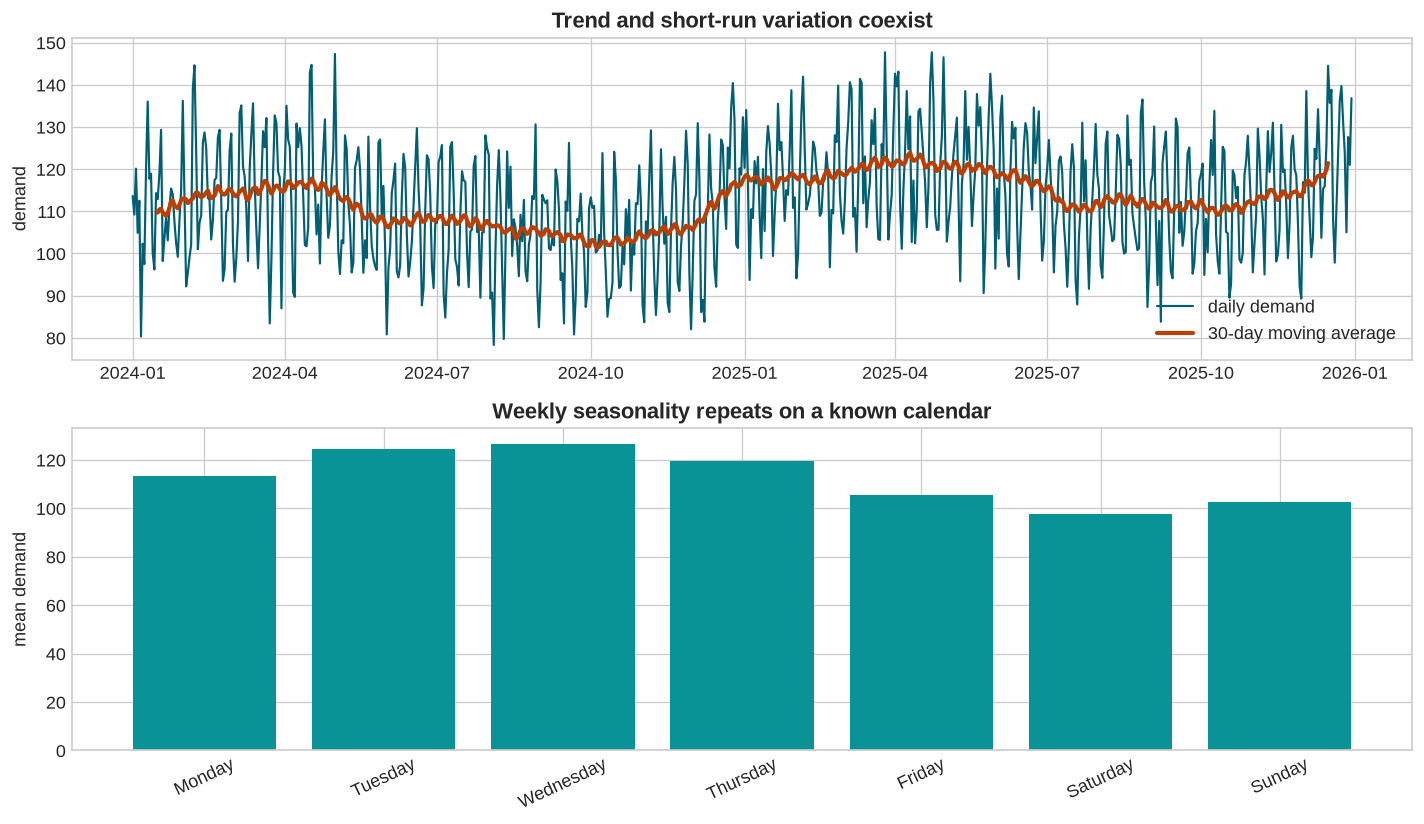

In [5]:
fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=False)
axes[0].plot(series.date,series.demand,c=TEAL,lw=1.3,label="daily demand")
axes[0].plot(series.date,series.demand.rolling(30,center=True).mean(),c=CORAL,lw=2.5,label="30-day moving average")
axes[0].set(title="Trend and short-run variation coexist",ylabel="demand"); axes[0].legend()
weekday=series.assign(weekday=series.date.dt.day_name()).groupby("weekday").demand.mean().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
axes[1].bar(weekday.index, weekday, color=MINT); axes[1].tick_params(axis="x", rotation=25); axes[1].set(title="Weekly seasonality repeats on a known calendar", ylabel="mean demand")
plt.tight_layout()

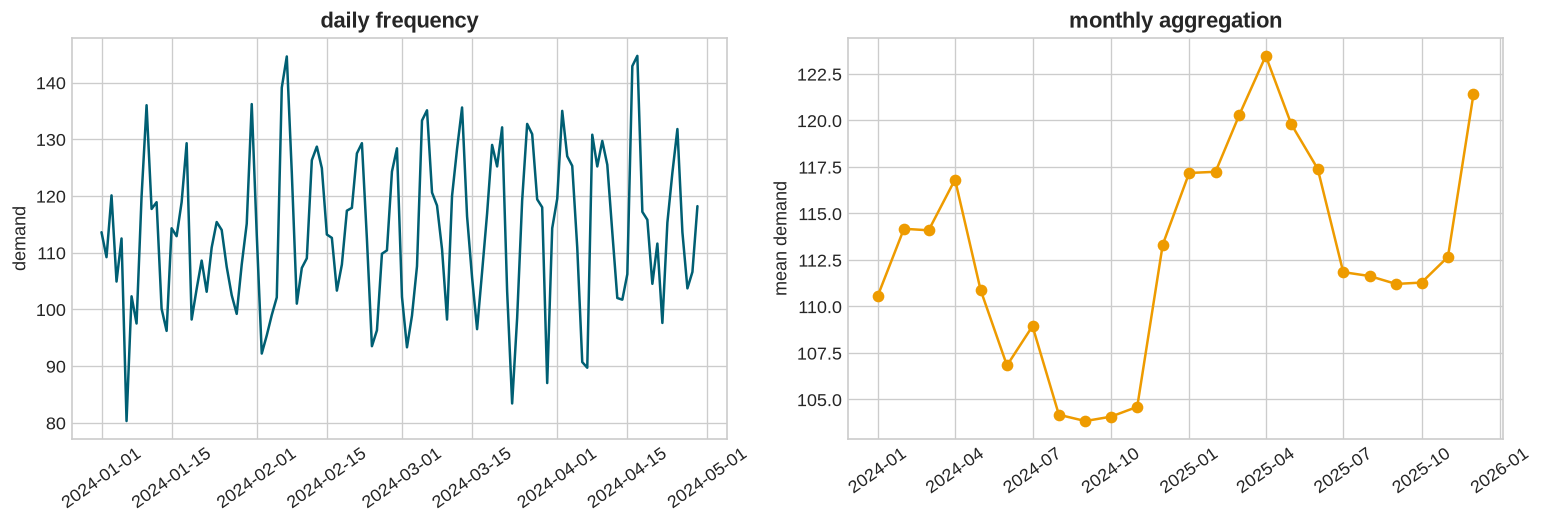

In [6]:
monthly=series.set_index("date").demand.resample("MS").mean()
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
axes[0].plot(series.date.iloc[:120],series.demand.iloc[:120],c=TEAL); axes[0].set(title="daily frequency",ylabel="demand")
axes[1].plot(monthly.index,monthly,c=GOLD,marker="o"); axes[1].set(title="monthly aggregation",ylabel="mean demand")
for ax in axes: ax.tick_params(axis="x",rotation=35)
plt.tight_layout()

<h2 id="3.-Moving-averages,-exponential-smoothing,-Holt-trend,-and-seasonal-state">3. Moving averages, exponential smoothing, Holt trend, and seasonal state</h2><p>Moving averages smooth by equally weighting a recent window. Exponential smoothing gives more weight to recent observations. Holt adds a trend state. Seasonal exponential smoothing also keeps a calendar state.</p>

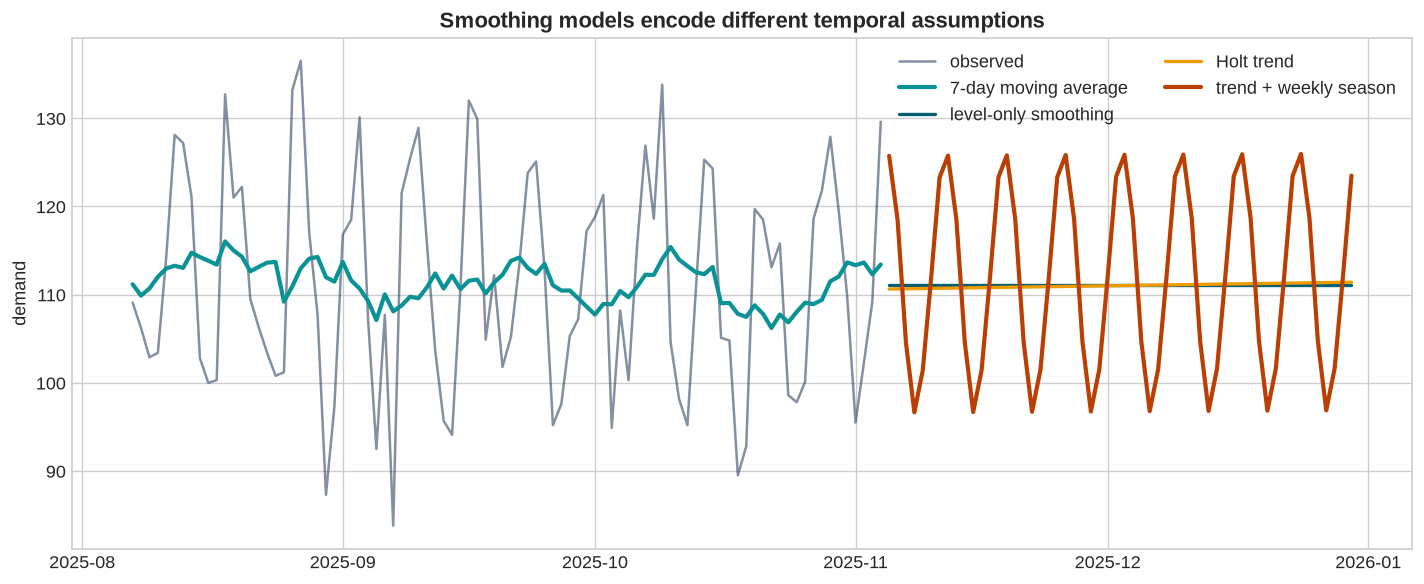

In [7]:
train=series.iloc[:-56].copy(); test=series.iloc[-56:].copy()
ma=train.demand.rolling(7).mean()
ets_level=ExponentialSmoothing(train.demand,trend=None,seasonal=None).fit()
ets_trend=ExponentialSmoothing(train.demand,trend="add",seasonal=None).fit()
ets_seasonal=ExponentialSmoothing(train.demand,trend="add",seasonal="add",seasonal_periods=7).fit()
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(train.date.iloc[-90:],train.demand.iloc[-90:],c=INK,alpha=.55,label="observed")
ax.plot(train.date.iloc[-90:],ma.iloc[-90:],c=MINT,lw=2.5,label="7-day moving average")
ax.plot(test.date,ets_level.forecast(len(test)),c=TEAL,lw=2,label="level-only smoothing")
ax.plot(test.date,ets_trend.forecast(len(test)),c=GOLD,lw=2,label="Holt trend")
ax.plot(test.date,ets_seasonal.forecast(len(test)),c=CORAL,lw=2.5,label="trend + weekly season")
ax.set(title="Smoothing models encode different temporal assumptions",ylabel="demand")
ax.legend(ncol=2); plt.tight_layout()

<h2 id="4.-Lag,-autocorrelation,-differencing,-and-ARIMA">4. Lag, autocorrelation, differencing, and ARIMA</h2><p>A lag compares the present with an earlier value. Autocorrelation summarizes this relationship across a lag. Differencing can remove a changing level before an autoregressive and moving-average model is fitted.</p>

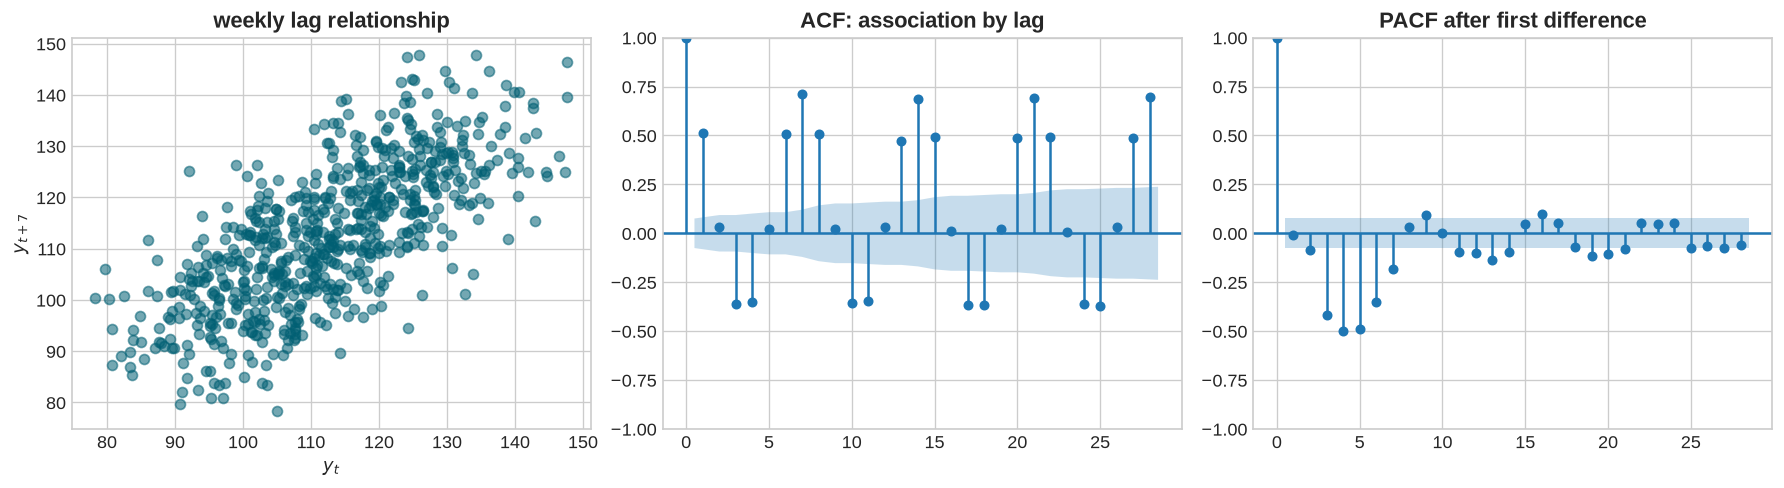

In [8]:
fig,axes=plt.subplots(1,3,figsize=(15,4.2))
axes[0].scatter(train.demand.iloc[:-7],train.demand.iloc[7:],c=TEAL,alpha=.55); axes[0].set(xlabel="$y_t$",ylabel="$y_{t+7}$",title="weekly lag relationship")
plot_acf(train.demand, lags=28,ax=axes[1]); axes[1].set_title("ACF: association by lag")
plot_pacf(train.demand.diff().dropna(),lags=28,ax=axes[2],method="ywm"); axes[2].set_title("PACF after first difference")
plt.tight_layout()

In [9]:
# Start from a valid stationary/invertible ARMA state rather than unstable
# automatically estimated starting values. The fitted model retains constraints.
arima_spec = ARIMA(train.demand, order=(1, 1, 1))
arima = arima_spec.fit(start_params=[0., 0., float(train.demand.diff().dropna().var())],
                       method_kwargs={"maxiter": 500})
assert arima.mle_retvals["converged"], "ARIMA optimisation needs further review"
seasonal_naive=np.resize(train.demand.iloc[-7:].to_numpy(),len(test))
forecast_frame=pd.DataFrame({"actual":test.demand.to_numpy(),"seasonal naive":seasonal_naive,"ETS seasonal":ets_seasonal.forecast(len(test)).to_numpy(),"ARIMA(1,1,1)":arima.forecast(len(test)).to_numpy()},index=test.date)
forecast_frame.apply(lambda col: mean_absolute_error(forecast_frame.actual,col)).drop("actual").rename("MAE")

seasonal naive     7.962500
ETS seasonal       8.062145
ARIMA(1,1,1)      11.944682
Name: MAE, dtype: float64

<h2 id="5.-Forecast-origin,-chronological-holdout,-and-rolling-origin-validation">5. Forecast origin, chronological holdout, and rolling-origin validation</h2><p>A random split lets a model learn from the future. A chronological holdout preserves the forecast origin. Rolling origin repeats that decision at several historical origins.</p>

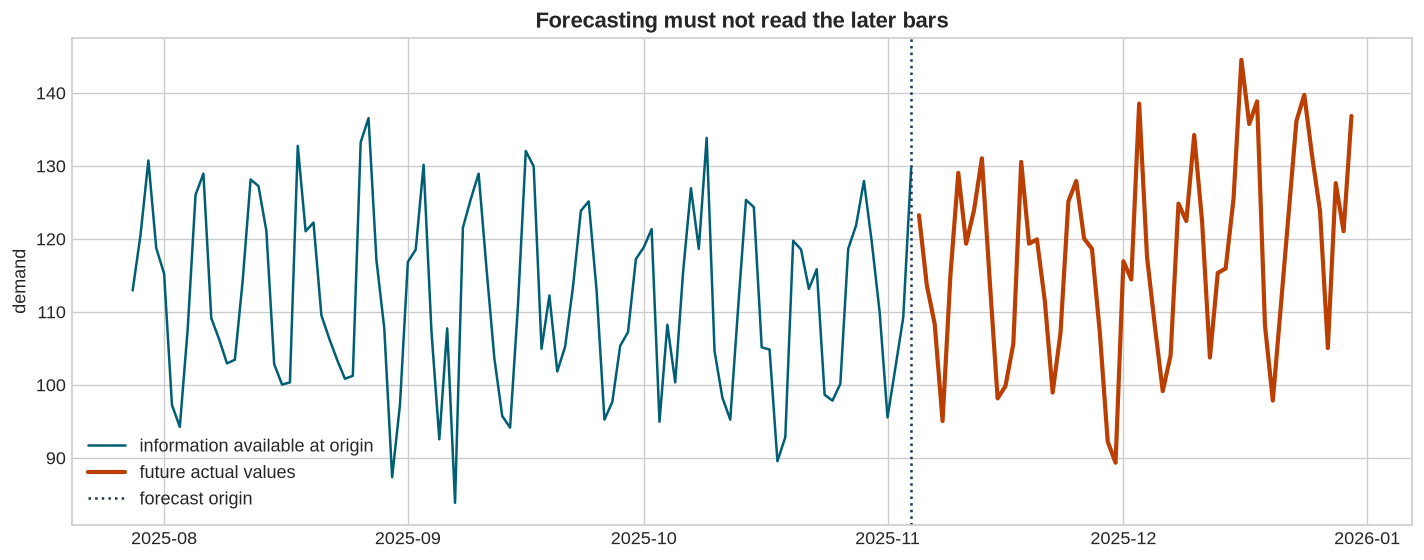

In [10]:
fig,ax=plt.subplots(figsize=(12,4.8))
ax.plot(train.date.iloc[-100:],train.demand.iloc[-100:],c=TEAL,label="information available at origin")
ax.plot(test.date,test.demand,c=CORAL,lw=2.5,label="future actual values")
ax.axvline(train.date.iloc[-1],c=INK,ls=":",label="forecast origin")
ax.set(title="Forecasting must not read the later bars",ylabel="demand"); ax.legend(); plt.tight_layout()

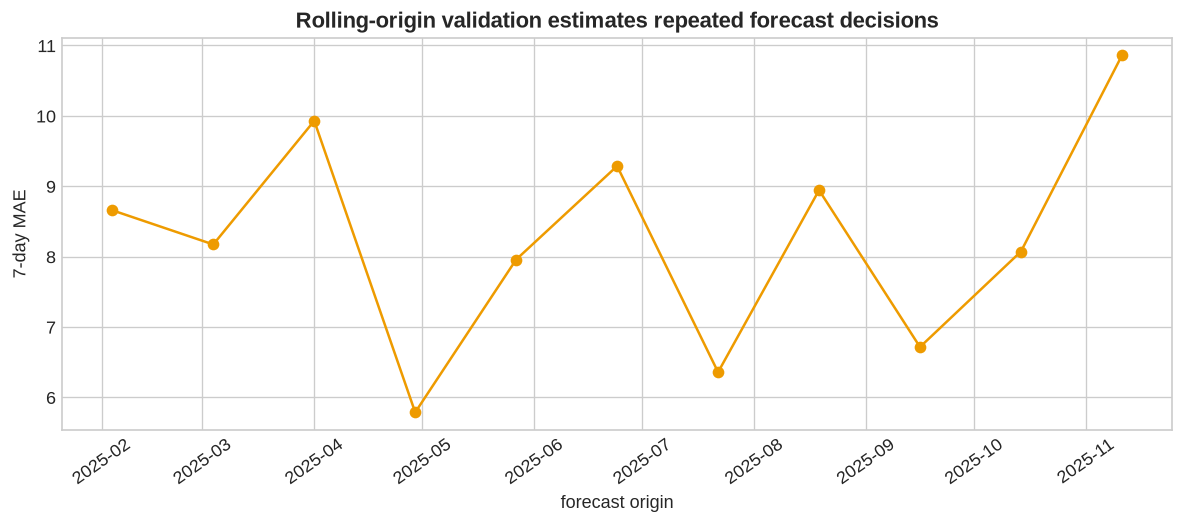

In [11]:
origins=range(400,len(series)-28,28); rolling=[]
for origin in origins:
    history=series.demand.iloc[:origin]; future=series.demand.iloc[origin:origin+7]
    pred=np.resize(history.iloc[-7:].to_numpy(),len(future))
    rolling.append((series.date.iloc[origin],mean_absolute_error(future,pred)))
rolling=pd.DataFrame(rolling,columns=["origin","MAE"])
fig,ax=plt.subplots(figsize=(10,4.5)); ax.plot(rolling.origin,rolling.MAE,"o-",c=GOLD)
ax.set(title="Rolling-origin validation estimates repeated forecast decisions",xlabel="forecast origin",ylabel="7-day MAE"); ax.tick_params(axis="x",rotation=35); plt.tight_layout()

<h2 id="6.-Error-metrics,-intervals,-anomalies,-and-structural-breaks">6. Error metrics, intervals, anomalies, and structural breaks</h2><p>MAE weights each error equally. RMSE squares large errors. A forecast interval communicates conditional uncertainty. An unusual point is a question, not an automatic deletion rule. A structural break can make old training history stale.</p>

MAE             8.06
RMSE           10.09
signed bias     5.77
dtype: float64


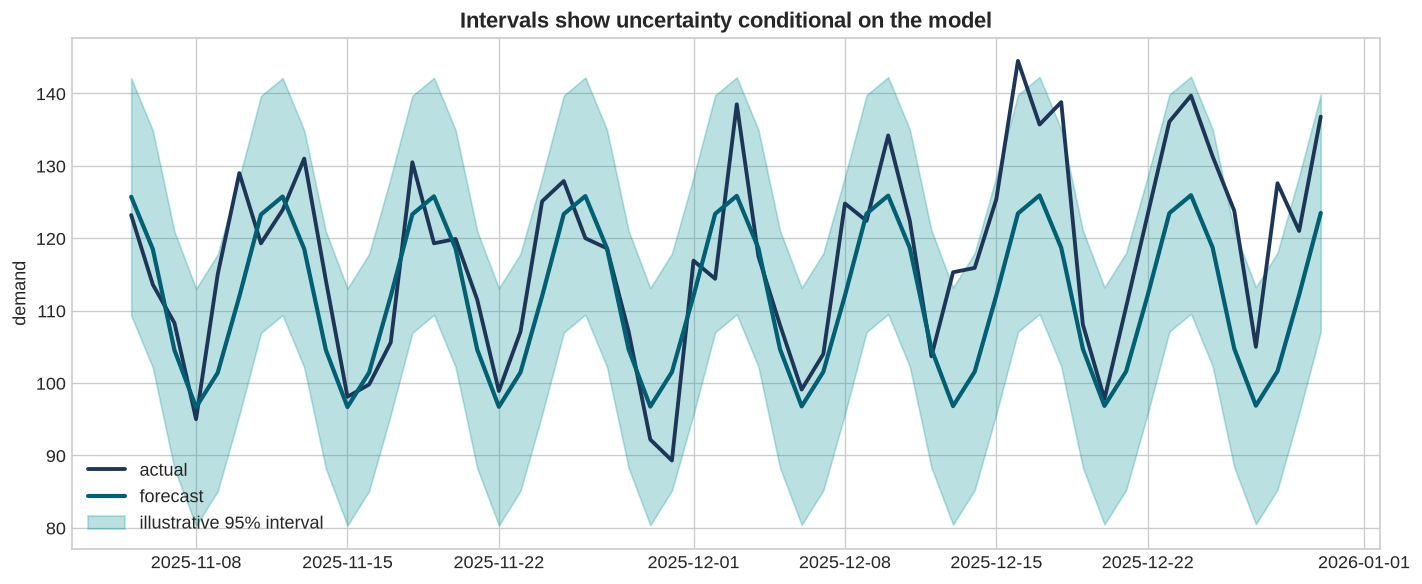

In [12]:
errors=forecast_frame.actual-forecast_frame["ETS seasonal"]
print(pd.Series({"MAE":mean_absolute_error(forecast_frame.actual,forecast_frame["ETS seasonal"]),"RMSE":mean_squared_error(forecast_frame.actual,forecast_frame["ETS seasonal"])**.5,"signed bias":errors.mean()}).round(2))
std=errors.std(); lower=forecast_frame["ETS seasonal"]-1.96*std; upper=forecast_frame["ETS seasonal"]+1.96*std
fig,ax=plt.subplots(figsize=(12,5)); ax.plot(forecast_frame.index,forecast_frame.actual,c=INK,lw=2.3,label="actual")
ax.plot(forecast_frame.index,forecast_frame["ETS seasonal"],c=TEAL,lw=2.5,label="forecast")
ax.fill_between(forecast_frame.index,lower,upper,color=MINT,alpha=.28,label="illustrative 95% interval")
ax.set(title="Intervals show uncertainty conditional on the model",ylabel="demand"); ax.legend(); plt.tight_layout()

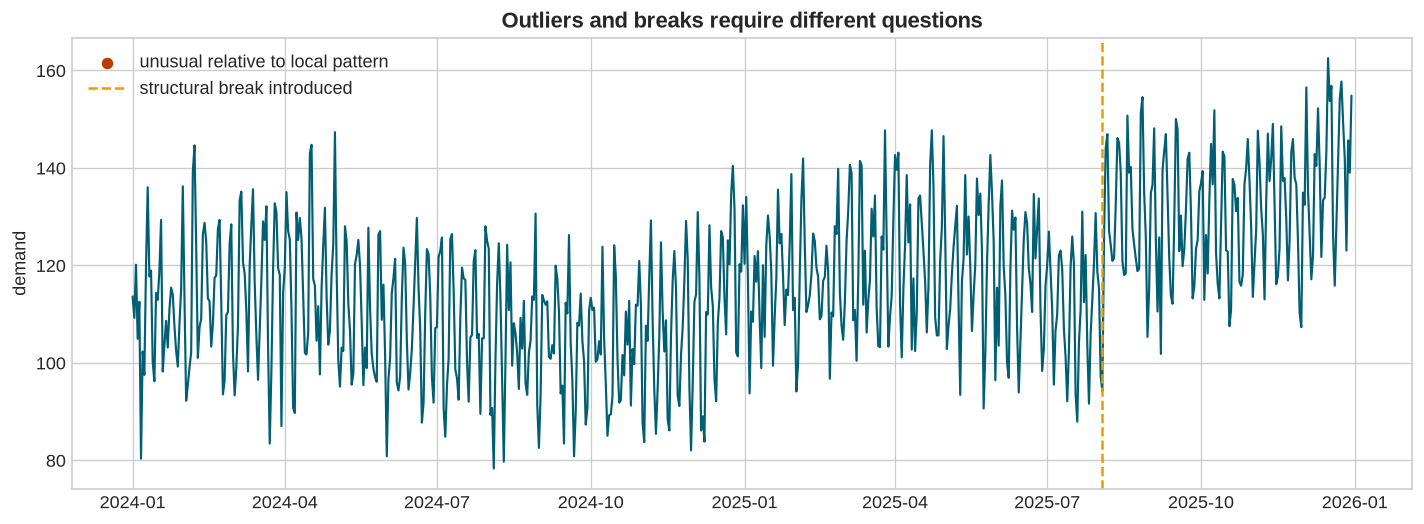

In [13]:
break_series=series.copy(); break_series["synthetic_break"]=break_series.demand+np.where(break_series.date>break_series.date.iloc[-150],18,0)
z=(break_series.synthetic_break-break_series.synthetic_break.rolling(30,center=True).mean())/break_series.synthetic_break.rolling(30,center=True).std()
fig,ax=plt.subplots(figsize=(12,4.5)); ax.plot(break_series.date,break_series.synthetic_break,c=TEAL,lw=1.3)
ax.scatter(break_series.date[abs(z)>2.5],break_series.synthetic_break[abs(z)>2.5],c=CORAL,s=35,label="unusual relative to local pattern")
ax.axvline(break_series.date.iloc[-150],c=GOLD,ls="--",label="structural break introduced")
ax.set(title="Outliers and breaks require different questions",ylabel="demand"); ax.legend(); plt.tight_layout()

<h2 id="Check-your-understanding">Check your understanding</h2><ol>
<li>Why can a random train/test split invalidate a forecast claim?</li>
<li>Which feature of the demand series is seasonality, and which is trend?</li>
<li>How does Holt's method differ from level-only smoothing?</li>
<li>Why is ARIMA a candidate to evaluate, not a default winner?</li>
<li>What operational decision would use an interval rather than a point forecast alone?</li>
</ol>

<h2 id="Applied-forecasting-lab:-observed-sunspots">Applied forecasting lab: observed sunspots</h2><p>This dataset contains annual sunspot observations collected since 1700. Each row has a calendar year and an observed count. The raw history comes first; the last 20 years then become a realistic future period for a simple hold-out forecast.</p>

In [14]:
from statsmodels.datasets import sunspots

sun = sunspots.load_pandas().data.rename(columns={"YEAR": "year", "SUNACTIVITY": "sunspots"})
sun.head(8)

,year,sunspots
0,1700.0,5.0
1,1701.0,11.0
2,1702.0,16.0
3,1703.0,23.0
4,1704.0,36.0
5,1705.0,58.0
6,1706.0,29.0
7,1707.0,20.0


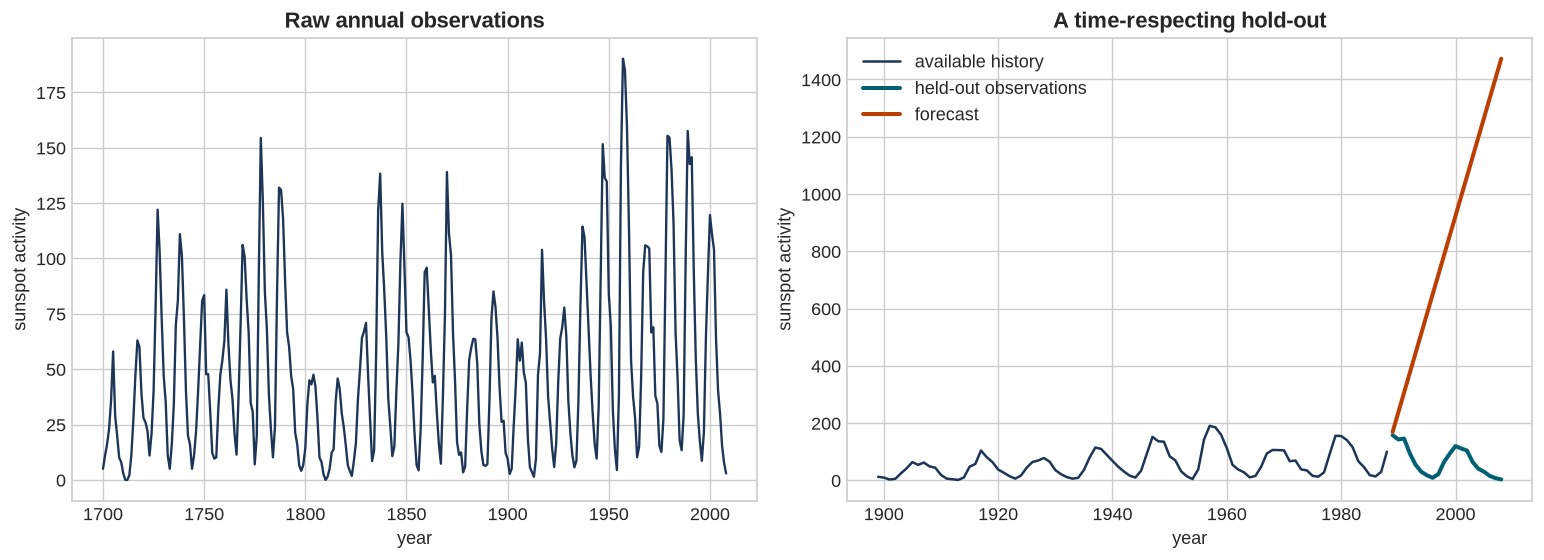

In [15]:
train, test = sun.iloc[:-20], sun.iloc[-20:]
sun_model = ExponentialSmoothing(train.sunspots, trend="add", initialization_method="estimated").fit(optimized=True)
forecast = sun_model.forecast(len(test))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(sun.year, sun.sunspots, color=INK, lw=1.4)
axes[0].set(title="Raw annual observations", xlabel="year", ylabel="sunspot activity")
axes[1].plot(train.year.iloc[-90:], train.sunspots.iloc[-90:], color=INK, lw=1.5, label="available history")
axes[1].plot(test.year, test.sunspots, color=TEAL, lw=2.4, label="held-out observations")
axes[1].plot(test.year, forecast, color=CORAL, lw=2.4, label="forecast")
axes[1].set(title="A time-respecting hold-out", xlabel="year", ylabel="sunspot activity"); axes[1].legend()
plt.tight_layout()

<p>This is the forecast workflow in miniature: preserve time order, hide a future block, forecast from the past, and compare predictions with the later observations.</p>